<span style='color:red'>

# TITLE: `DATA EXPLORATION AND ANALYSIS`

</span>

---
---
---

<span style='color:red'>

# 1. DATA EXPLORATION INTRODUCTION


---

<div style='background-color:lightgray; padding:15px;'>

<span style='color:black'>

1. Data Exploration and Analysis is where you begin to find patterns, relationships, and insights in the data.

2. This part of the process is usually combined with data visualization and data cleaning.

3. You can explore your data finding correlations, creating visualizations, aggregating data and more.

---

<center><img src='images/13.png' width=570></center>

---

</div>

---

---
---
---

<span style='color:red'>

# 2. A FIRST LOOK AT THE DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
aliens = pd.read_csv('datasets/alien_sightings.csv')
aliens.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88679 entries, 0 to 88678
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              88679 non-null  object 
 1   city                  88679 non-null  object 
 2   state                 81270 non-null  object 
 3   country               76314 non-null  object 
 4   shape                 85757 non-null  object 
 5   duration (seconds)    88677 non-null  object 
 6   duration (hours/min)  85660 non-null  object 
 7   comments              88644 non-null  object 
 8   date posted           88679 non-null  object 
 9   latitude              88679 non-null  object 
 10  longitude             88679 non-null  float64
dtypes: float64(1), object(10)
memory usage: 7.4+ MB


C:\Users\Milton Valle_Pro\AppData\Local\Temp\ipykernel_7948\2345909712.py:1: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  aliens = pd.read_csv('datasets/alien_sightings.csv')


In [3]:
aliens.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [4]:
# NAN Values are...
aliens.isna().sum()

datetime                    0
city                        0
state                    7409
country                 12365
shape                    2922
duration (seconds)          2
duration (hours/min)     3019
comments                   35
date posted                 0
latitude                    0
longitude                   0
dtype: int64

In [5]:
# The unique values per column are...
aliens.nunique()

datetime                75957
city                    22018
state                      68
country                     5
shape                      29
duration (seconds)        730
duration (hours/min)     9708
comments                88283
date posted               317
latitude                25407
longitude               20549
dtype: int64

In [6]:
aliens['datetime'].value_counts()

datetime
7/4/2010 22:00      36
7/4/2012 22:00      33
11/16/1999 19:00    28
10/31/2004 20:00    26
9/19/2009 20:00     26
                    ..
10/31/1999 18:15     1
9/9/2012 21:55       1
9/9/2012 23:00       1
9/9/2013 0:15        1
10/10/1949 20:30     1
Name: count, Length: 75957, dtype: int64

In [7]:
# I will take a look at the most older and most recent date present in this DataFrame...
aliens.sort_values(by='datetime', ascending=True)

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
11920,1/1/1944 10:00,wilderness (near western md),wv,NaN,disk,1814400,3 weeks,US fighter planes shoot down pre Roswell UFO t...,3/21/2003,0,0.000000
11921,1/1/1944 12:00,san diego,ca,us,cigar,180,3 minutes,A sighting of one silver or white enlongated c...,7/25/2004,32.7152778,-117.156389
11922,1/1/1944 12:00,wilderness,wv,NaN,disk,1814400,3 weeks,Two related reports of possible predecessor to...,7/8/2004,0,0.000000
11923,1/1/1945 12:00,ft. lee,va,NaN,cigar,0,short,Multi-colored object near Army base&#44 1945,4/16/2005,37.249053,-77.332431
11924,1/1/1947 17:00,manama (bahrain),NaN,NaN,circle,300,5 minutes,Slow moving circular craft&#44 15 whitnesses&...,3/19/2009,26.216667,50.583333
...,...,...,...,...,...,...,...,...,...,...,...
88676,9/9/2013 23:00,edmond,ok,us,cigar,1020.0,17 minutes,2 witnesses 2 miles apart&#44 Red &amp; White...,9/30/2013,35.652778,-97.477778
88677,9/9/2013 23:00,starr,sc,us,diamond,0.0,2 nights,On September ninth my wife and i noticed stran...,9/30/2013,34.376944,-82.695833
88678,9/9/2013 23:30,ft. lauderdale,fl,us,oval,0.0,still occuring,Hovering object lit with red and white lights&...,9/30/2013,26.121944,-80.143611
88656,9/9/2013 3:00,struthers,oh,us,unknown,120.0,2 minutes,I saw a routaing line of stares that seemed to...,9/9/2013,41.0525,-80.608056


In [8]:
# I need to format the "datetime" columns into a correct datetime...
aliens['datetime'] = pd.to_datetime(aliens['datetime'])

# Now I will take again a new general look of the DataFrame
aliens.sort_values(by='datetime')

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
8686,1906-11-11 00:00:00,wien (austria),NaN,NaN,other,10800,3 h,The oldest professional photo of a UFO object ...,12/23/2002,48.208174,16.373819
11672,1910-01-02 00:00:00,kirksville (near),mo,us,disk,120,minutes,Historical sighting (1903 - 1913) Northern Mis...,9/15/2005,40.1947222,-92.583056
49458,1910-05-28 21:00:00,solon,me,us,unknown,0,don&#39t know,entry in my great-grandmother&#39s diary&#44da...,12/5/2001,44.9494444,-69.858889
51857,1910-06-01 15:00:00,wills point,tx,us,cigar,120,2 minutes,Cigar shaped object moving from West to East,4/16/2005,32.7091667,-96.008056
82297,1914-09-15 21:30:00,meeting lake (canada),ab,NaN,unknown,0.0,NaN,Night flying &quot;airplane&quot; with search ...,2/1/2007,55.170828,-118.837956
...,...,...,...,...,...,...,...,...,...,...,...
51088,2014-05-07 21:20:00,hillsboro,mo,us,fireball,360,4-6 minutes,Round slow moving silent ball looked like a ca...,5/8/2014,38.2322222,-90.562778
51089,2014-05-07 22:45:00,dalton,ga,us,NaN,0,NaN,May 7&#44 2014&#44 I saw an extremely fast-mov...,5/8/2014,34.7697222,-84.970278
51090,2014-05-07 23:30:00,san isidro,nm,NaN,unknown,15,15 seconds,2 red lights gliding across sky&#44 then green...,5/8/2014,35.563363,-106.770591
51244,2014-05-08 00:00:00,memphis,tn,us,rectangle,900,15 minutes,Standing at my window around 0:00 brilliantly ...,5/8/2014,35.1494444,-90.048889


In [ ]:
aliens.d

---
---
---

<span style='color:red'>

# 3. GROUPING AND VISUALIZING DATA

In [9]:
insurance = pd.read_csv('datasets/health_insurance.csv')
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df_region = insurance.groupby(by='region')['charges'].mean().reset_index()
df_region.sort_values('charges')

,region,charges
3,southwest,12346.937377
1,northwest,12417.575374
0,northeast,13406.384516
2,southeast,14735.411438


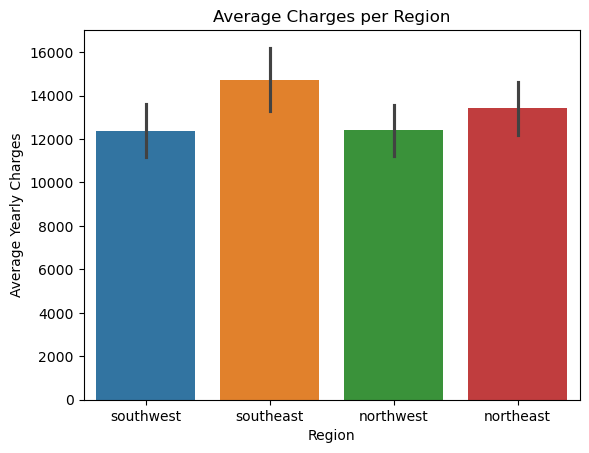

In [11]:
sns.barplot(data=insurance, x='region', y='charges', hue='region')
plt.xlabel('Region')
plt.ylabel('Average Yearly Charges')
plt.title('Average Charges per Region')
plt.show()

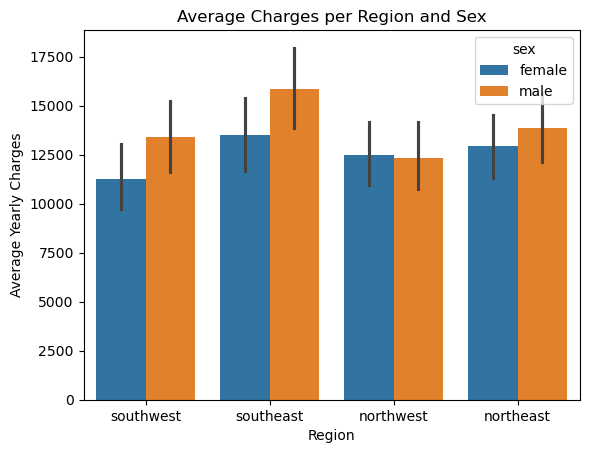

In [12]:
sns.barplot(data=insurance, x='region', y='charges', hue='sex')
plt.xlabel('Region')
plt.ylabel('Average Yearly Charges')
plt.title('Average Charges per Region and Sex')
plt.show()

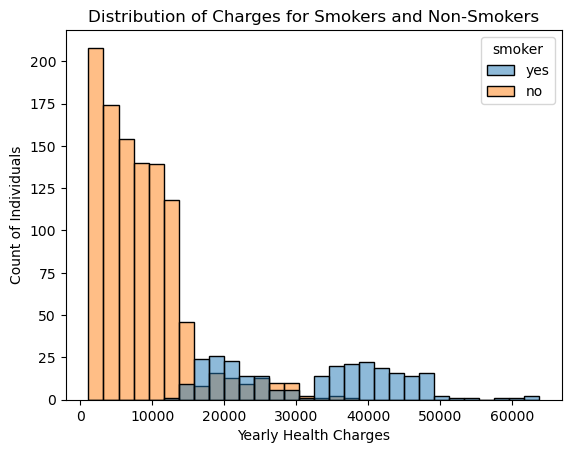

In [13]:
sns.histplot(data=insurance, x='charges', hue='smoker')
plt.xlabel('Yearly Health Charges')
plt.ylabel('Count of Individuals')
plt.title('Distribution of Charges for Smokers and Non-Smokers')
plt.show()

In [14]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


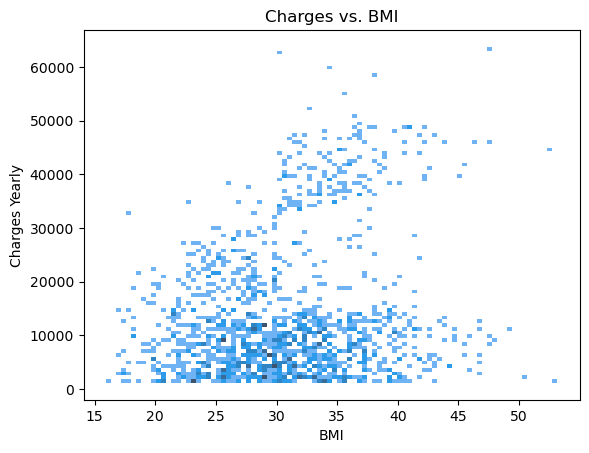

In [15]:
sns.histplot(data=insurance, x='bmi', y='charges', bins=90)
plt.xlabel('BMI')
plt.ylabel('Charges Yearly')
plt.title('Charges vs. BMI')
plt.show()

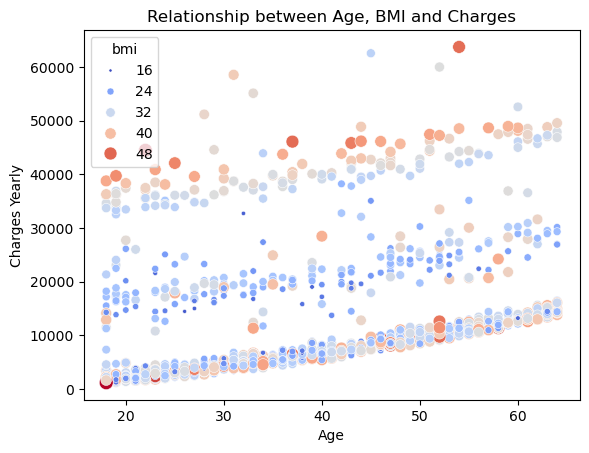

In [16]:
sns.scatterplot(data=insurance, x='age', y='charges', hue='bmi', size='bmi', sizes=(5, 100), palette='coolwarm')
plt.xlabel('Age')
plt.ylabel('Charges Yearly')
plt.title('Relationship between Age, BMI and Charges')
plt.show()

---
---
---

<span style='color:red'>

# 4. CORRELATION AND COVARIANCE


---

`Around the 2:50 mark, MSRP.corr() requires the numeric_only = True argument to function. This also applies when trying to create the corr_msrp variable with MSRP.corr(). The library was updated so this may be needed!`

---

---
---

<span style='color:red'>

## 4.1. Correlations



In [17]:
df_cars = pd.read_csv('datasets/car_sales.csv')
df_cars

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


<Axes: >

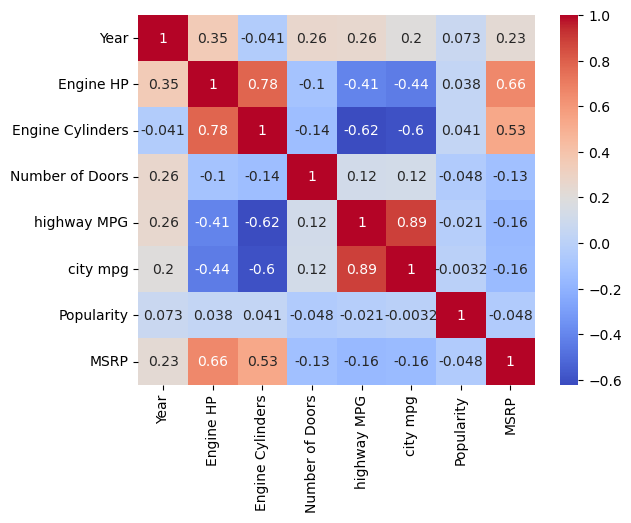

In [18]:
cars_corr = df_cars.corr(numeric_only=True)
sns.heatmap(data=cars_corr, annot=True, cmap='coolwarm')

---
---

In [19]:
# When the dataframe is very well, well cleaned. We can use the "PEARSON" Method. Otherwise the Outliers will affect
# ...really bad on the correlation matrix calculation
cars_corr.corr(method='pearson', numeric_only=True)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
Year,1.000000,0.047676,-0.211012,0.246637,0.208638,0.159234,-0.223201,-0.005505
Engine HP,0.047676,1.000000,0.954318,-0.458792,-0.892914,-0.908087,-0.093403,0.888801
Engine Cylinders,-0.211012,0.954318,1.000000,-0.448320,-0.961679,-0.961241,-0.011820,0.828026
Number of Doors,0.246637,-0.458792,-0.448320,1.000000,0.276323,0.272315,-0.238200,-0.539646
highway MPG,0.208638,-0.892914,-0.961679,0.276323,1.000000,0.993317,-0.140769,-0.712092
city mpg,0.159234,-0.908087,-0.961241,0.272315,0.993317,1.000000,-0.126257,-0.720235
Popularity,-0.223201,-0.093403,-0.011820,-0.238200,-0.140769,-0.126257,1.000000,-0.247101
MSRP,-0.005505,0.888801,0.828026,-0.539646,-0.712092,-0.720235,-0.247101,1.000000


In [20]:
# When the DataFrame is raw and not well cleaned, we can use the "SPEARMAN" Method. The outliers with this method 
# ...are excluded, that is why we get better results.
cars_corr.corr(method='spearman', numeric_only=True)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
Year,1.000000,0.095238,-0.238095,0.547619,0.285714,0.238095,-0.142857,0.047619
Engine HP,0.095238,1.000000,0.928571,-0.666667,-0.880952,-0.904762,0.214286,0.904762
Engine Cylinders,-0.238095,0.928571,1.000000,-0.761905,-0.976190,-0.952381,0.285714,0.880952
Number of Doors,0.547619,-0.666667,-0.761905,1.000000,0.738095,0.761905,-0.071429,-0.642857
highway MPG,0.285714,-0.880952,-0.976190,0.738095,1.000000,0.976190,-0.166667,-0.833333
city mpg,0.238095,-0.904762,-0.952381,0.761905,0.976190,1.000000,-0.142857,-0.809524
Popularity,-0.142857,0.214286,0.285714,-0.071429,-0.166667,-0.142857,1.000000,0.023810
MSRP,0.047619,0.904762,0.880952,-0.642857,-0.833333,-0.809524,0.023810,1.000000


In [21]:
# The "KENDALL" method takes the outliers out, and this method might take a lot of time for it's correlation 
# ...matrix calculations. This METHOD DEMANDS TO KNOW VERY WELL YOUR DATAFRAME.
cars_corr.corr(method='kendall', numeric_only=True)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
Year,1.000000,0.071429,-0.142857,0.428571,0.214286,0.142857,-0.071429,0.000000
Engine HP,0.071429,1.000000,0.785714,-0.500000,-0.714286,-0.785714,0.000000,0.785714
Engine Cylinders,-0.142857,0.785714,1.000000,-0.571429,-0.928571,-0.857143,0.214286,0.714286
Number of Doors,0.428571,-0.500000,-0.571429,1.000000,0.500000,0.571429,-0.071429,-0.428571
highway MPG,0.214286,-0.714286,-0.928571,0.500000,1.000000,0.928571,-0.142857,-0.642857
city mpg,0.142857,-0.785714,-0.857143,0.571429,0.928571,1.000000,-0.071429,-0.571429
Popularity,-0.071429,0.000000,0.214286,-0.071429,-0.142857,-0.071429,1.000000,-0.071429
MSRP,0.000000,0.785714,0.714286,-0.428571,-0.642857,-0.571429,-0.071429,1.000000


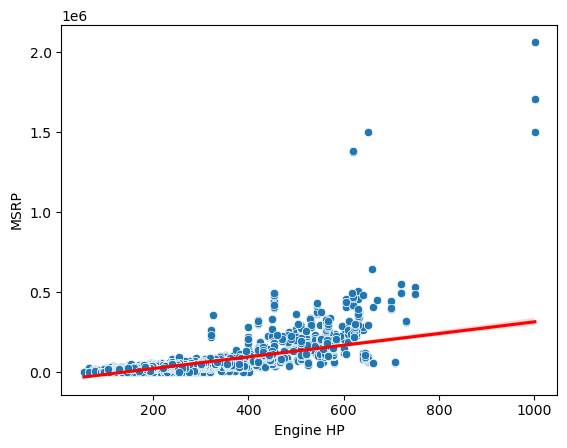

In [22]:
sns.scatterplot(data=df_cars, x='Engine HP', y='MSRP')

sns.regplot(data=df_cars, x='Engine HP', y='MSRP', scatter=False, color='red')

plt.show()

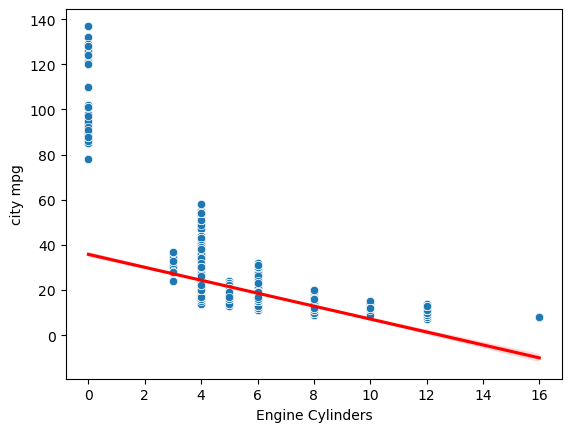

In [23]:
sns.scatterplot(data=df_cars, x='Engine Cylinders', y='city mpg')
sns.regplot(data=df_cars, x='Engine Cylinders', y='city mpg', scatter=False, color='red')
plt.show()

---
---

<span style='color:red'>

## 4.2. Covarians



In [24]:
df_cars.cov(numeric_only=True)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
Year,57.452457,2.915880e+02,-0.560066,1.762368,17.348355,13.500413,7.983461e+02,1.036924e+05
Engine HP,291.588019,1.192286e+04,149.338158,-9.892033,-342.948789,-340.853727,5.891934e+03,4.355284e+06
Engine Cylinders,-0.560066,1.493382e+02,3.170392,-0.219406,-9.516859,-9.084998,1.057135e+02,5.693262e+04
Number of Doors,1.762368,-9.892033e+00,-0.219406,0.776717,0.911541,0.942308,-6.135446e+01,-6.704131e+03
highway MPG,17.348355,-3.429488e+02,-9.516859,0.911541,78.552783,70.643828,-2.682478e+02,-8.526226e+04
city mpg,13.500413,-3.408537e+02,-9.084998,0.942308,70.643828,80.780516,-4.168582e+01,-8.518407e+04
Popularity,798.346061,5.891934e+03,105.713515,-61.354465,-268.247758,-41.685824,2.078947e+06,-4.201369e+06
MSRP,103692.370363,4.355284e+06,56932.619101,-6704.130906,-85262.262046,-85184.071075,-4.201369e+06,3.613104e+09


---
---
---

<span style='color:red'>

# 5. TIME SERIES ANALYSIS


---


In [25]:
aliens = pd.read_csv('datasets/alien_sightings.csv')
aliens.head()

C:\Users\Milton Valle_Pro\AppData\Local\Temp\ipykernel_7948\4102449083.py:1: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  aliens = pd.read_csv('datasets/alien_sightings.csv')


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [26]:
aliens['datetime'] = pd.to_datetime(aliens['datetime'])
aliens.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88679 entries, 0 to 88678
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              88679 non-null  datetime64[ns]
 1   city                  88679 non-null  object        
 2   state                 81270 non-null  object        
 3   country               76314 non-null  object        
 4   shape                 85757 non-null  object        
 5   duration (seconds)    88677 non-null  object        
 6   duration (hours/min)  85660 non-null  object        
 7   comments              88644 non-null  object        
 8   date posted           88679 non-null  object        
 9   latitude              88679 non-null  object        
 10  longitude             88679 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 7.4+ MB


In [27]:
aliens['duration (seconds)'] = pd.to_numeric(aliens['duration (seconds)'])

ValueError: Unable to parse string "2`" at position 30821

In [28]:
aliens['duration (seconds)'] = aliens['duration (seconds)'].str.replace('`', '')

In [29]:
aliens['duration (seconds)'] = pd.to_numeric(aliens['duration (seconds)'])

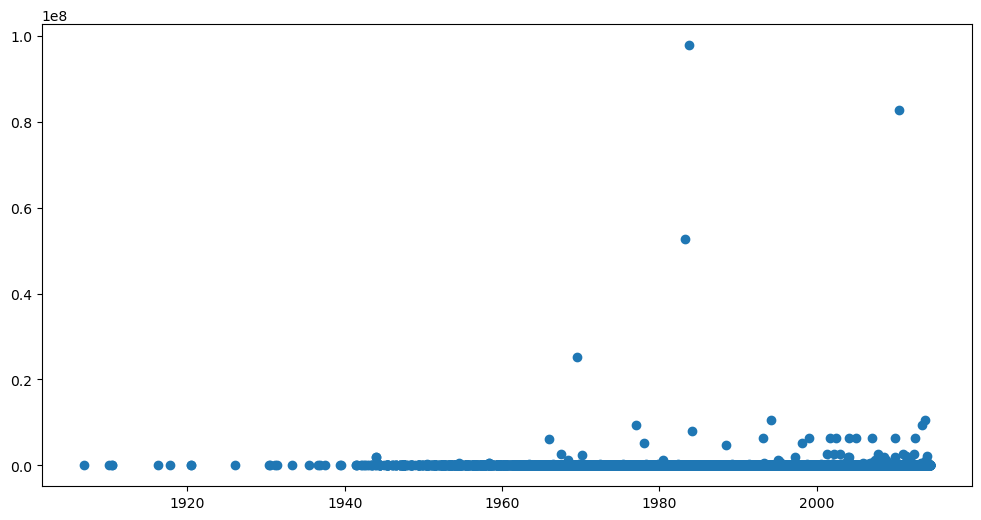

In [30]:
plt.figure(figsize=(12, 6))
plt.scatter(aliens['datetime'], aliens['duration (seconds)'])
plt.show()

In [31]:
aliens.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700.0,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200.0,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20.0,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20.0,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900.0,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [32]:
aliens.set_index(keys='datetime', inplace=True)
aliens.head()

,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
datetime,,,,,,,,,,
1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700.0,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200.0,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20.0,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
1956-10-10 21:00:00,edna,tx,us,circle,20.0,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
1960-10-10 20:00:00,kaneohe,hi,us,light,900.0,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [33]:
aliens.resample('M').count()

C:\Users\Milton Valle_Pro\AppData\Local\Temp\ipykernel_7948\2575998408.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  aliens.resample('M').count()


,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
datetime,,,,,,,,,,
1906-11-30,1,0,0,1,1,1,1,1,1,1
1906-12-31,0,0,0,0,0,0,0,0,0,0
1907-01-31,0,0,0,0,0,0,0,0,0,0
1907-02-28,0,0,0,0,0,0,0,0,0,0
1907-03-31,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
2014-01-31,696,664,623,678,696,679,696,696,696,696
2014-02-28,528,506,472,518,528,509,528,528,528,528
2014-03-31,496,456,442,487,496,480,496,496,496,496


In [34]:
monthly_counts = aliens.resample('ME').count()

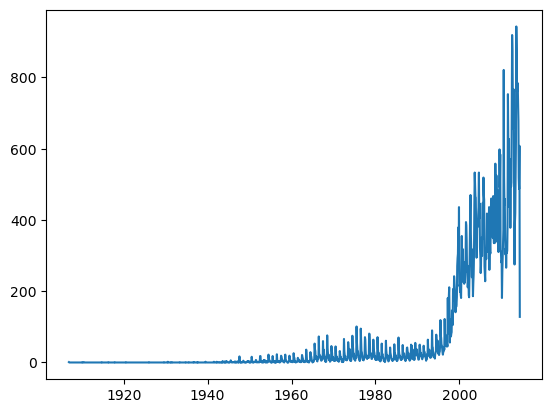

In [35]:
plt.plot(monthly_counts.index, monthly_counts['shape'])
plt.show()

In [36]:
year_counts = aliens.resample('YE').count()


In [37]:
year_counts.tail()

,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
datetime,,,,,,,,,,
2010-12-31,4690,4340,4119,4605,3210,4544,4690,4690,4690,4690
2011-12-31,5521,5238,4879,5431,3854,5388,5520,5521,5521,5521
2012-12-31,7924,7528,7113,7811,5701,7739,7924,7924,7924,7924
2013-12-31,7599,7284,6830,7480,5282,7427,7597,7599,7599,7599
2014-12-31,2473,2335,2206,2419,2473,2407,2473,2473,2473,2473


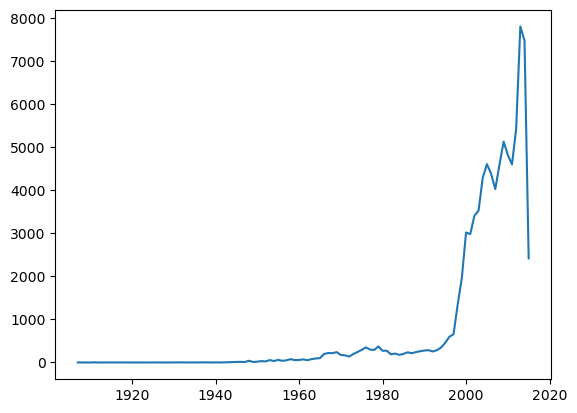

In [38]:
plt.plot(year_counts.index, year_counts['shape'])
plt.show()

In [39]:
sightings_country = aliens.groupby('country').resample('ME').size().unstack(level=0)

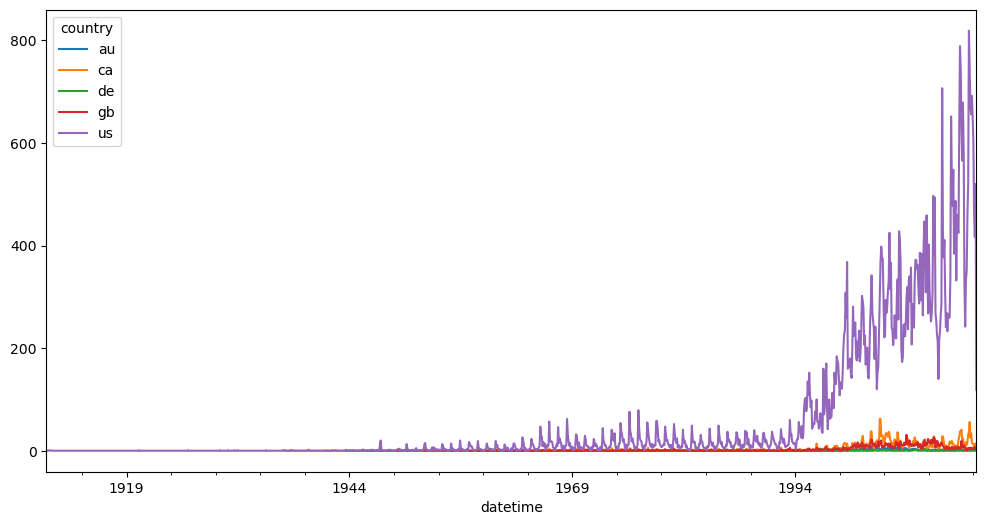

In [40]:
sightings_country.plot(figsize=(12, 6))
plt.show()